# Tuần 2 — Train Random Forest v1

**Người phụ trách:** Bạn B · **Tham chiếu:** `Plan.md` mục 3 (Tuần 2) + mục 7.

Mục tiêu:

1. Train RF baseline: **GridSearchCV + StratifiedKFold (k=5)** trên **81 đặc trưng** (87 − 6 cột hằng số).
2. Số liệu k-fold **mean ± std**: precision / recall / f1 / roc_auc.
3. Đánh giá trên tập test giữ lại (20%).
4. Lấy `feature_importances_` → đầu vào cho feature selection Tuần 3.

Logic nằm trong `src/train_rf.py`; notebook chỉ gọi lại + trình bày.
Chạy lại tất cả: `python -m src.train_rf` (grid rút gọn) hoặc `--full`.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image
from src import train_rf
from src.contracts import MODEL_FEATURES_V1, CONSTANT_FEATURES_DATASET_B

print(f'Đặc trưng đưa vào RF v1: {len(MODEL_FEATURES_V1)}  (87 - {len(CONSTANT_FEATURES_DATASET_B)} cột hằng số)')

Đặc trưng đưa vào RF v1: 81  (87 - 6 cột hằng số)


## 1. Chạy GridSearchCV + k-fold

Grid rút gọn: `n_estimators`∈{200,400} × `max_depth`∈{None,30} × `min_samples_leaf`∈{1,2} × `max_features`∈{sqrt,0.5} = 16 cấu hình × 5 fold. ~1 phút CPU.

> Nếu `reports/rf_v1/summary.json` đã có, cell dưới vẫn train lại từ đầu (kết quả cố định vì `random_state=42`).

In [2]:
summary = train_rf.run(full_grid=False)

Đã bỏ 1 dòng URL trùng (11430 → 11429).
Train 9143 / Test 2286 | 81 đặc trưng
GridSearchCV: 16 cấu hình × 5 fold = 80 lần fit
Fitting 5 folds for each of 16 candidates, totalling 80 fits


{
  "n_train": 9143,
  "n_test": 2286,
  "n_features_in": 81,
  "grid": "quick",
  "best_params": {
    "max_depth": null,
    "max_features": "sqrt",
    "min_samples_leaf": 1,
    "n_estimators": 400
  },
  "kfold_mean_std": {
    "precision": {
      "mean": 0.9678,
      "std": 0.0052
    },
    "recall": {
      "mean": 0.9654,
      "std": 0.0058
    },
    "f1": {
      "mean": 0.9666,
      "std": 0.0017
    },
    "roc_auc": {
      "mean": 0.9935,
      "std": 0.0007
    }
  },
  "test_metrics": {
    "precision_phishing": 0.9591,
    "recall_phishing": 0.9633,
    "f1_phishing": 0.9612,
    "accuracy": 0.9611,
    "roc_auc": 0.9924
  },
  "top15_importances": {
    "google_index": 0.1897,
    "page_rank": 0.109,
    "nb_hyperlinks": 0.0824,
    "web_traffic": 0.0756,
    "nb_www": 0.0414,
    "ratio_extHyperlinks": 0.0316,
    "domain_age": 0.0302,
    "longest_word_path": 0.0261,
    "ratio_intHyperlinks": 0.0252,
    "safe_anchor": 0.0247,
    "phish_hints": 0.0244,
    "r

## 2. Số liệu k-fold (mean ± std) tại cấu hình tốt nhất

In [3]:
print('Cấu hình tốt nhất:', json.dumps(summary['best_params'], ensure_ascii=False))
kf = summary['kfold_mean_std']
pd.DataFrame({m: {'mean': v['mean'], 'std': v['std']} for m, v in kf.items()}).T

Cấu hình tốt nhất: {"max_depth": null, "max_features": "sqrt", "min_samples_leaf": 1, "n_estimators": 400}


,mean,std
precision,0.9678,0.0052
recall,0.9654,0.0058
f1,0.9666,0.0017
roc_auc,0.9935,0.0007


In [4]:
pd.DataFrame(summary['test_metrics'], index=['test (2286 URL giữ lại)']).T

,test (2286 URL giữ lại)
precision_phishing,0.9591
recall_phishing,0.9633
f1_phishing,0.9612
accuracy,0.9611
roc_auc,0.9924


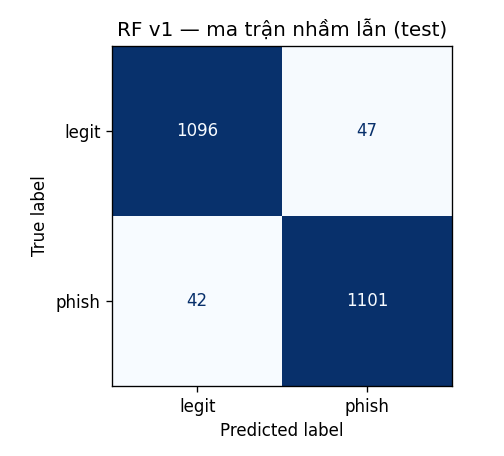

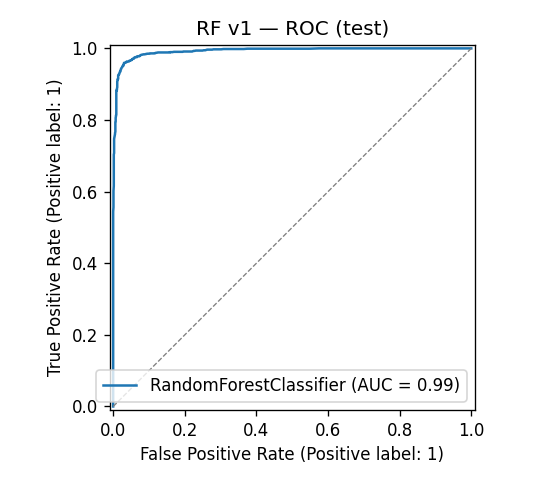

In [5]:
display(Image(str(train_rf.OUT_DIR / 'fig_confusion.png')))
display(Image(str(train_rf.OUT_DIR / 'fig_roc.png')))

## 3. Feature importances → chuẩn bị feature selection (Tuần 3)

In [6]:
imp = pd.read_csv(train_rf.OUT_DIR / 'feature_importances.csv', index_col=0)['importance']
cum = imp.cumsum()
print(f"Top 30 đặc trưng gộp {cum.iloc[29]:.1%} tổng importance | Top 42: {cum.iloc[41]:.1%}")
print(f"Số đặc trưng có importance < 0.005: {(imp < 0.005).sum()}/{len(imp)}")
imp.head(20).to_frame()

Top 30 đặc trưng gộp 90.6% tổng importance | Top 42: 96.8%
Số đặc trưng có importance < 0.005: 45/81


,importance
dac_trung,
google_index,0.189660
page_rank,0.108992
nb_hyperlinks,0.082401
web_traffic,0.075619
nb_www,0.041378
ratio_extHyperlinks,0.031599
domain_age,0.030191
longest_word_path,0.026131
ratio_intHyperlinks,0.025236


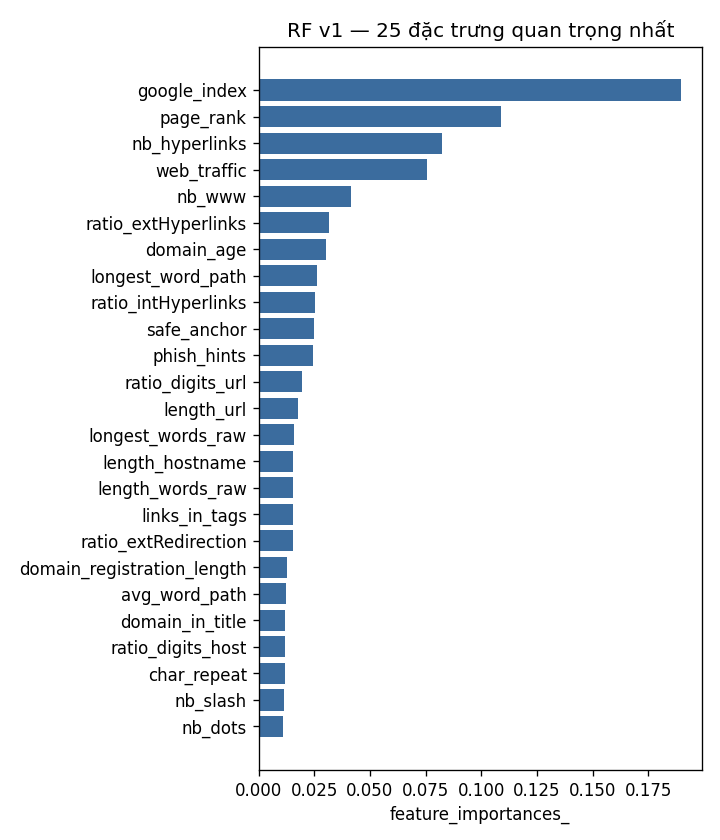

In [7]:
display(Image(str(train_rf.OUT_DIR / 'fig_importances.png')))

## 4. Nhận xét

- Baseline rất mạnh trên tập cân bằng (ROC-AUC k-fold ~0.993, độ lệch chuẩn nhỏ → ổn định giữa các fold).
- **`google_index` + `page_rank` + `web_traffic` + `domain_age`** (4 đặc trưng tra cứu ngoài) chiếm ~40% tổng importance → khớp cảnh báo EDA Tuần 1 về **độ giòn khi tra cứu ngoài lỗi/timeout**. Tuần 3 nên train thêm 1 bản "chỉ đặc trưng nhanh" (lexical + nội dung) để so.
- ~45/81 đặc trưng có importance < 0.005 → cắt xuống ~30–42 đặc trưng gần như không mất tín hiệu (đúng kế hoạch).
- Số liệu này **KHÔNG** dùng để chốt ngưỡng phân vùng — tập 50/50, phải hiệu chỉnh lại trên traffic 95/5 ở Tuần 6.

Chi tiết: `reports/rf_v1/BAO_CAO_RF_V1.md`.